In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('SMSSpamCollection',sep='\t',header=None,names=['label', 'message'])

In [5]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.shape

(5572, 2)

In [9]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [11]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [13]:
df.duplicated().sum()

403

In [19]:
# Dataset after removing duplicates
df = df.drop_duplicates()
df.shape

(5169, 2)

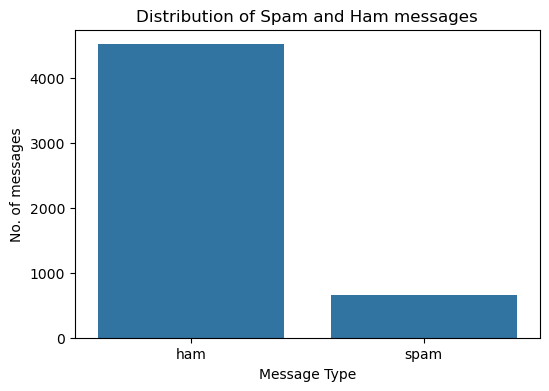

In [21]:
plt.figure(figsize = (6,4))
sns.countplot(data=df, x="label")
plt.title("Distribution of Spam and Ham messages")
plt.xlabel("Message Type")
plt.ylabel("No. of messages")
plt.show()

In [23]:
df["label_num"] = df["label"].map({"ham" : 0, "spam" : 1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## Text preprocessing

In [26]:
import nltk
import re

In [28]:
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/manasvimukhiyar/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [30]:
stop_words = set(stopwords.words("english"))

In [32]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [34]:
df["clean_message"] = df['message'].apply(preprocess_text)

df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

In [49]:
X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [53]:
len(X_train)

4135

In [55]:
len(X_test)

1034

## TF-IDF Feature Extraction

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [62]:
tfidf = TfidfVectorizer(max_features = 5000, ngram_range = (1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [68]:
X_train_tfidf.shape

(4135, 5000)

In [70]:
X_test_tfidf.shape

(1034, 5000)

## Multinomial Naive Bayes

In [73]:
nb_model = MultinomialNB()

In [75]:
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print('Model trained successfully')

Model trained successfully


In [77]:
## Naives Bayes Model Evaluation

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

In [79]:
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")

Accuracy : 0.9671
Precision: 1.0000
Recall   : 0.7405
F1 Score : 0.8509


In [81]:
## Classification report
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.96      1034



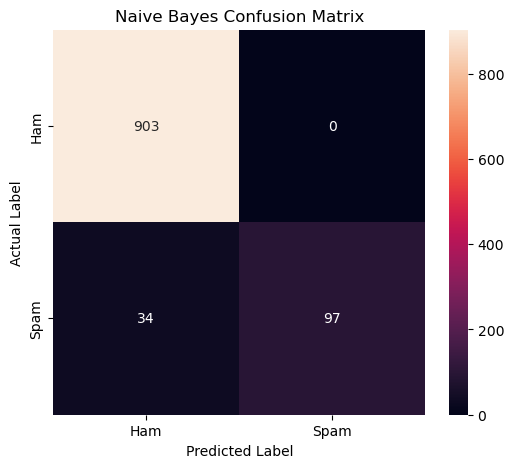

In [83]:
## Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Logistic Regression

In [86]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Model trained successfully.")

Model trained successfully.


In [88]:
## Evaluate Model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

In [90]:
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

Accuracy : 0.9555
Precision: 0.9474
Recall   : 0.6870
F1 Score : 0.7965


In [94]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [accuracy_nb, accuracy_lr],
    "Precision": [precision_nb, precision_lr],
    "Recall": [recall_nb, recall_lr],
    "F1 Score": [f1_nb, f1_lr]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.967118,1.000000,0.740458,0.850877
1,Logistic Regression,0.955513,0.947368,0.687023,0.796460


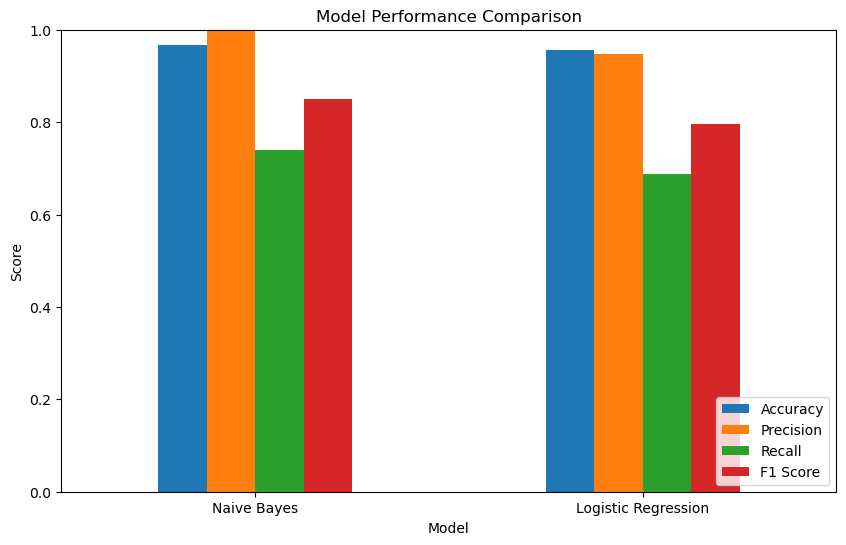

In [96]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

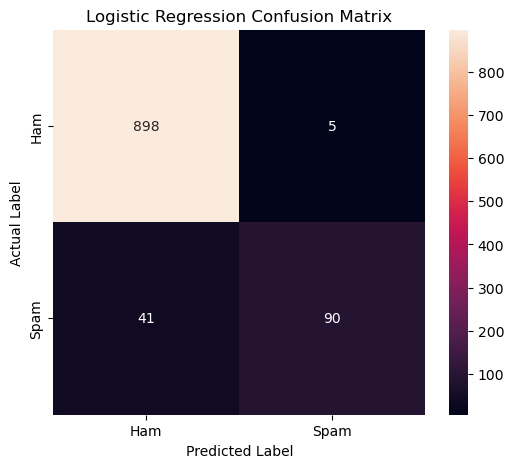

In [98]:
## Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Testing the Spam Detector on New Messages

In [ ]:
new_messages = [
    "Congratulations! You have won a free prize. Claim your reward now!",
    "Hey, are you coming to class today?",
    "URGENT! You have been selected for a cash prize. Call now!",
    "Can you send me the notes from today's lecture?",
    "Get 50% discount on your next purchase. Limited time offer!"
]

new_messages_clean = [preprocess_text(msg) for msg in new_messages]

new_messages_tfidf = tfidf.transform(new_messages_clean)

predictions = nb_model.predict(new_messages_tfidf)

for message, prediction in zip(new_messages, predictions):
    label = "SPAM" if prediction == 1 else "HAM"
    print(f"Message: {message}")
    print(f"Prediction: {label}")
    print("-" * 70)

In [103]:
prediction_results = pd.DataFrame({
    "Message": new_messages,
    "Prediction": ["SPAM" if p == 1 else "HAM" for p in predictions]
})

prediction_results

,Message,Prediction
0,Congratulations! You have won a free prize. Cl...,SPAM
1,"Hey, are you coming to class today?",HAM
2,URGENT! You have been selected for a cash priz...,SPAM
3,Can you send me the notes from today's lecture?,HAM
4,Get 50% discount on your next purchase. Limite...,HAM


In [110]:
import joblib

joblib.dump(nb_model, "spam_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


## Improved Text Preprocessing


In [113]:
def preprocess_text_v2(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


df["clean_message_v2"] = df["message"].apply(preprocess_text_v2)

df[["message", "clean_message_v2"]].head()

,message,clean_message_v2
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## Retraining using improved preprocessing

In [118]:
X = df["clean_message_v2"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf_v2 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf_v2 = tfidf_v2.fit_transform(X_train)
X_test_tfidf_v2 = tfidf_v2.transform(X_test)

In [120]:
nb_model_v2 = MultinomialNB()

nb_model_v2.fit(X_train_tfidf_v2, y_train)

y_pred_nb_v2 = nb_model_v2.predict(X_test_tfidf_v2)

In [122]:
accuracy_nb_v2 = accuracy_score(y_test, y_pred_nb_v2)
precision_nb_v2 = precision_score(y_test, y_pred_nb_v2)
recall_nb_v2 = recall_score(y_test, y_pred_nb_v2)
f1_nb_v2 = f1_score(y_test, y_pred_nb_v2)

In [124]:
print(f"Accuracy : {accuracy_nb_v2:.4f}")
print(f"Precision: {precision_nb_v2:.4f}")
print(f"Recall   : {recall_nb_v2:.4f}")
print(f"F1 Score : {f1_nb_v2:.4f}")

Accuracy : 0.9671
Precision: 1.0000
Recall   : 0.7405
F1 Score : 0.8509


In [126]:
new_messages_clean_v2 = [
    preprocess_text_v2(msg) for msg in new_messages
]

new_messages_tfidf_v2 = tfidf_v2.transform(new_messages_clean_v2)

predictions_v2 = nb_model_v2.predict(new_messages_tfidf_v2)

prediction_results_v2 = pd.DataFrame({
    "Message": new_messages,
    "Prediction": [
        "SPAM" if p == 1 else "HAM"
        for p in predictions_v2
    ]
})

prediction_results_v2

,Message,Prediction
0,Congratulations! You have won a free prize. Cl...,SPAM
1,"Hey, are you coming to class today?",HAM
2,URGENT! You have been selected for a cash priz...,SPAM
3,Can you send me the notes from today's lecture?,HAM
4,Get 50% discount on your next purchase. Limite...,HAM


In [128]:
comparison_nb = pd.DataFrame({
    "Version": ["Original Naive Bayes", "Improved Naive Bayes"],
    "Accuracy": [accuracy_nb, accuracy_nb_v2],
    "Precision": [precision_nb, precision_nb_v2],
    "Recall": [recall_nb, recall_nb_v2],
    "F1 Score": [f1_nb, f1_nb_v2]
})

comparison_nb

,Version,Accuracy,Precision,Recall,F1 Score
0,Original Naive Bayes,0.967118,1.0,0.740458,0.850877
1,Improved Naive Bayes,0.967118,1.0,0.740458,0.850877


In [130]:
joblib.dump(nb_model_v2, "spam_classifier.pkl")
joblib.dump(tfidf_v2, "tfidf_vectorizer.pkl")
print("Final model and vectorizer saved successfully.")

Final model and vectorizer saved successfully.


## Final Evaluation

In [133]:
print(classification_report(y_test, y_pred_nb_v2, target_names=["Ham", "Spam"]))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.96      1034



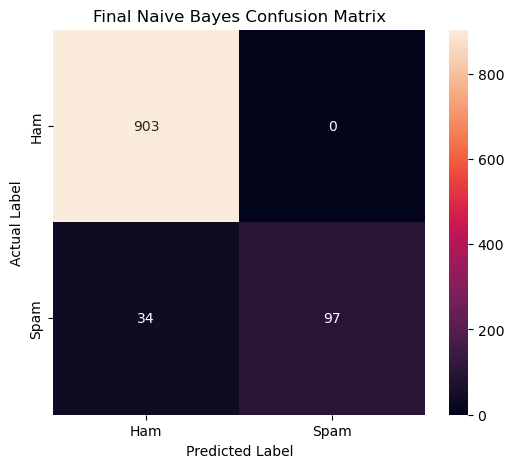

In [135]:
cm_final = confusion_matrix(y_test, y_pred_nb_v2)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Final Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()